In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv('onlinefraud.csv')
dataset.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
dataset.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [4]:
dataset.shape

(6362620, 11)

In [5]:
dataset.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
dataset.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
dataset.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
dataset.duplicated().sum()

np.int64(0)

In [10]:
dataset = dataset.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

The columns nameOrig and nameDest were dropped as they are unique IDs with no predictive value and can cause overfitting.
isFlaggedFraud was dropped due to extreme imbalance, low usefulness, and potential bias from existing rules.

In [11]:
dataset.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


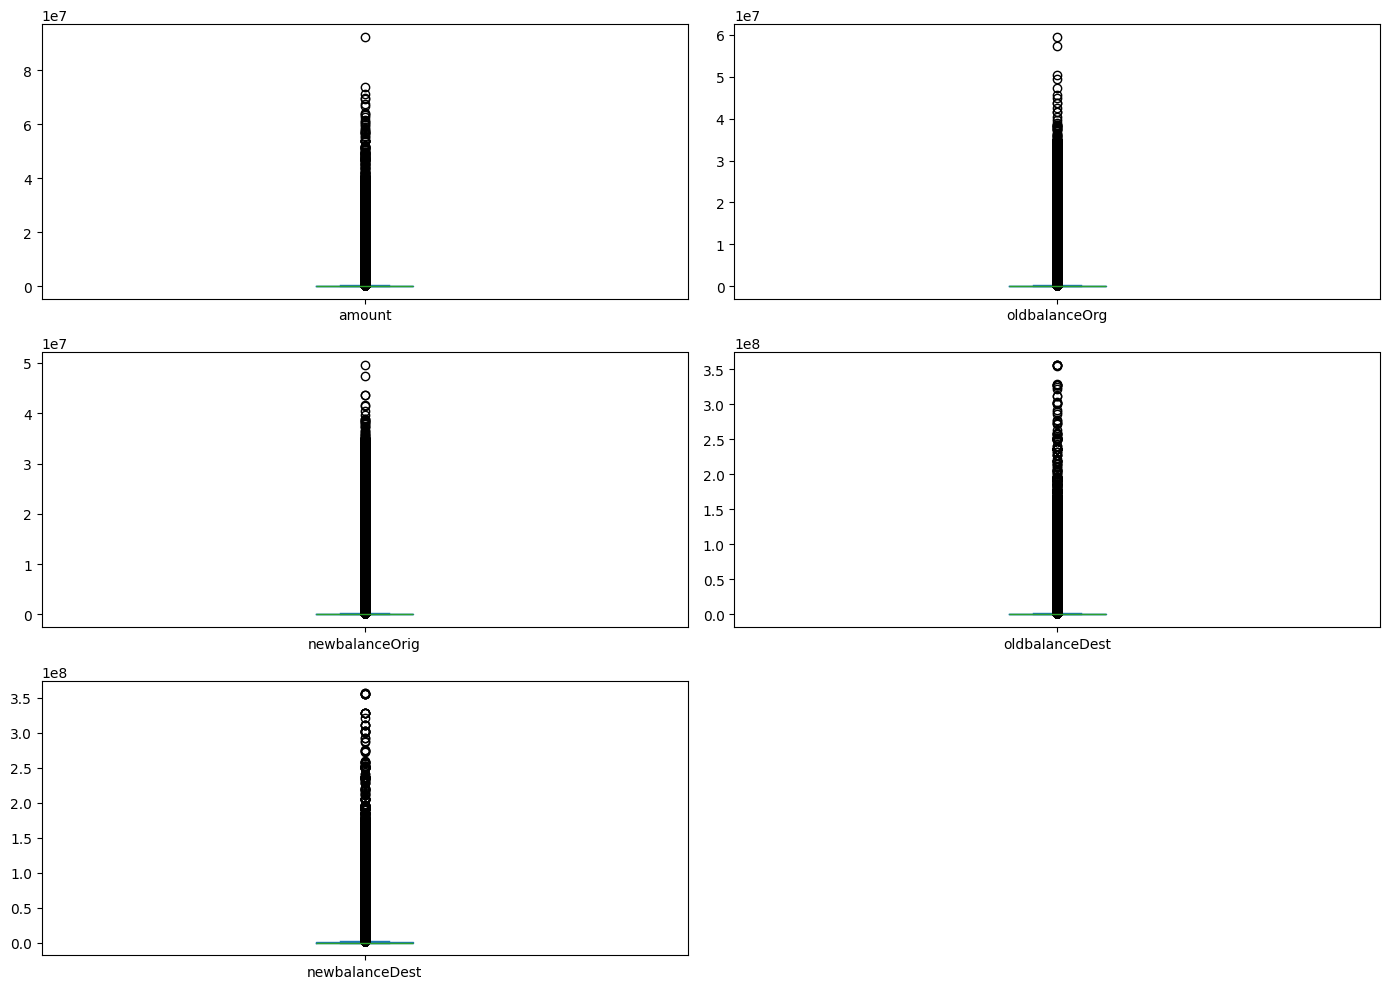

In [12]:
cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
dataset[cols].plot(kind= 'box', subplots=True, layout=(3,2), figsize=(14, 10))
plt.tight_layout()
plt.show()

Outliers were kept because they likely represent suspicious or abnormal behavior rather than noise. Removing them could eliminate critical patterns and detect such unusual activity.

In [13]:
dataset['OrgbalanceDiff'] = dataset['oldbalanceOrg'] - dataset['newbalanceOrig']
dataset['DestbalanceDiff'] = dataset['newbalanceDest'] - dataset['oldbalanceDest']

In [14]:
dataset['OrgbalanceDiff'].value_counts()

OrgbalanceDiff
 0.00         2089037
 184.00           737
 181.00           732
 186.00           731
 195.00           728
               ...   
-66162.60           1
-47035.61           1
-125604.06          1
-117164.81          1
 1308.02            1
Name: count, Length: 2962285, dtype: int64

In [15]:
dataset['DestbalanceDiff'].value_counts()

DestbalanceDiff
 0.00           2317292
 10000000.00        136
-10000.00            77
-5000.00             75
-15000.00            63
                 ...   
 255470.52            1
 371527.58            1
 67884.96             1
 112935.86            1
 850002.52            1
Name: count, Length: 4011056, dtype: int64

In [16]:
dataset['step'].value_counts()

step
19     51352
18     49579
187    49083
235    47491
307    46968
       ...  
432        4
706        4
693        4
112        2
662        2
Name: count, Length: 743, dtype: int64

In [17]:
dataset['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [18]:
dataset['amount'].value_counts()

amount
10000000.00    3207
10000.00         88
5000.00          79
15000.00         68
500.00           65
               ... 
8513.48           1
189137.90         1
1615.78           1
128891.19         1
12257.89          1
Name: count, Length: 5316900, dtype: int64

In [19]:
dataset['oldbalanceOrg'].value_counts()

oldbalanceOrg
0.00         2102449
184.00           918
133.00           914
195.00           912
164.00           909
              ...   
34577.49           1
184929.21          1
29320.33           1
82645.19           1
641239.85          1
Name: count, Length: 1845844, dtype: int64

In [20]:
dataset['newbalanceOrig'].value_counts()

newbalanceOrig
0.00         3609566
5888.64            4
15073.44           4
5122.00            4
36875.73           4
              ...   
51345.64           1
46527.23           1
30839.51           1
25521.75           1
160296.36          1
Name: count, Length: 2682586, dtype: int64

In [21]:
dataset['oldbalanceDest'].value_counts()

oldbalanceDest
0.00           2704388
10000000.00        615
20000000.00        219
30000000.00         86
40000000.00         31
                ...   
967022.27            1
327279.67            1
2039554.04           1
587552.25            1
6510099.11           1
Name: count, Length: 3614697, dtype: int64

In [22]:
dataset['newbalanceDest'].value_counts()

newbalanceDest
0.00           2439433
10000000.00         53
971418.91           32
19169204.93         29
1254956.07          25
                ...   
188439.36            1
1347758.15           1
3878719.83           1
1605826.83           1
7360101.63           1
Name: count, Length: 3555499, dtype: int64

In [23]:
dataset['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

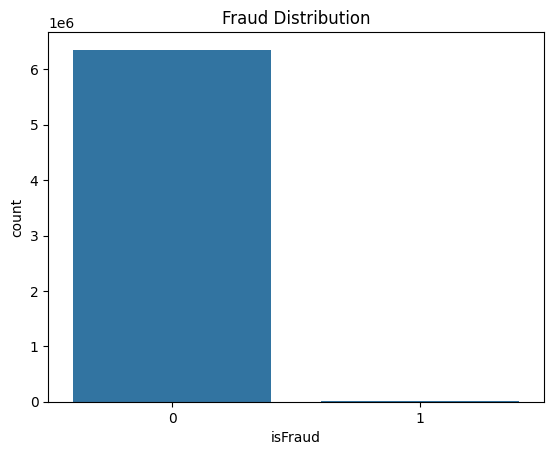

In [24]:
# Fraud distribution
sns.countplot(x='isFraud', data= dataset)
plt.title('Fraud Distribution')
plt.show()

In [25]:
fraud_by_type = dataset.groupby('type')['isFraud'].sum()
fraud_by_type

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

Fraud is observed only in CASH_OUT and TRANSFER transactions, with zero cases in other types, highligthting them as the main sources of abnormal activity.

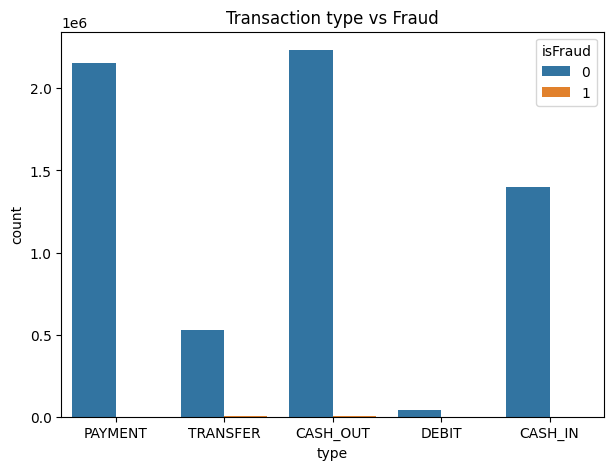

In [26]:
# Transaction type vs fraud
plt.figure(figsize= (7, 5))
sns.countplot(x='type', hue='isFraud', data= dataset)
plt.title('Transaction type vs Fraud')
plt.show()

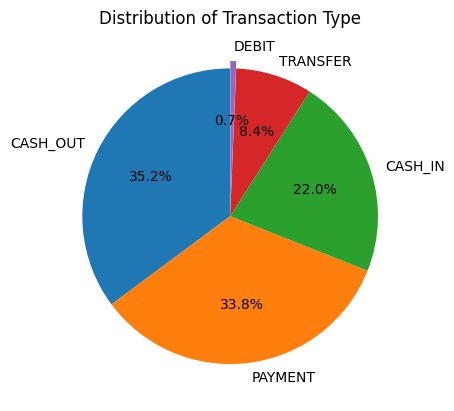

In [27]:
type = dataset["type"].value_counts()
transactions = type.index
quantity = type.values

plt.pie(type, labels= transactions, autopct= '%1.1f%%', startangle= 90, explode= [0, 0, 0, 0, 0.05])
plt.title('Distribution of Transaction Type')
plt.show()

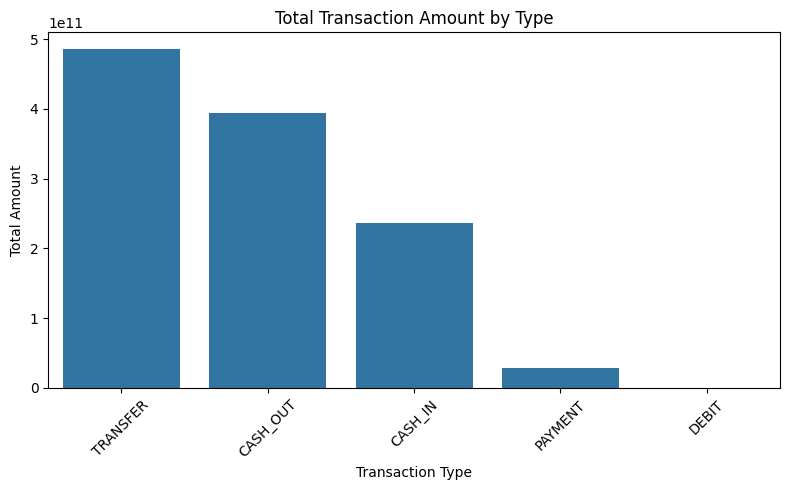

In [28]:
grouped_amount = dataset.groupby('type')['amount'].sum().sort_values(ascending=False)
grouped_amount
plt.figure(figsize=(8,5))
sns.barplot(x=grouped_amount.index, y=grouped_amount.values)

plt.xlabel('Transaction Type')
plt.ylabel('Total Amount')
plt.title('Total Transaction Amount by Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

TRANSFER has the highest total transaction amount, followed by CASH_OUT, while DEBIT contributes the least, indicating that most money flows through transfers and withdrawals rather than debit activities.

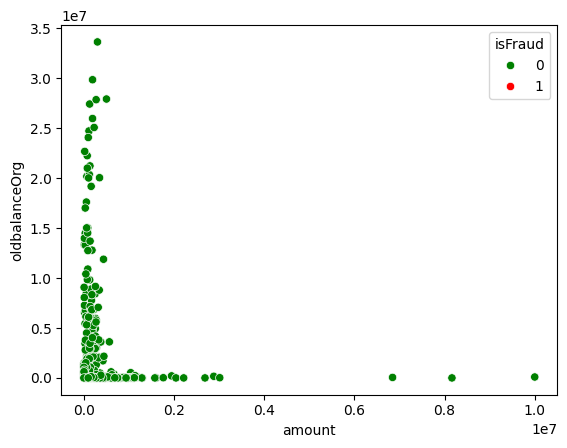

In [29]:
sns.scatterplot(x= 'amount',
                y= 'oldbalanceOrg',
                hue= 'isFraud',
                palette= {1: 'red', 0: 'green'},
                data= dataset.sample(1000))
plt.show()

<Figure size 1500x1000 with 0 Axes>

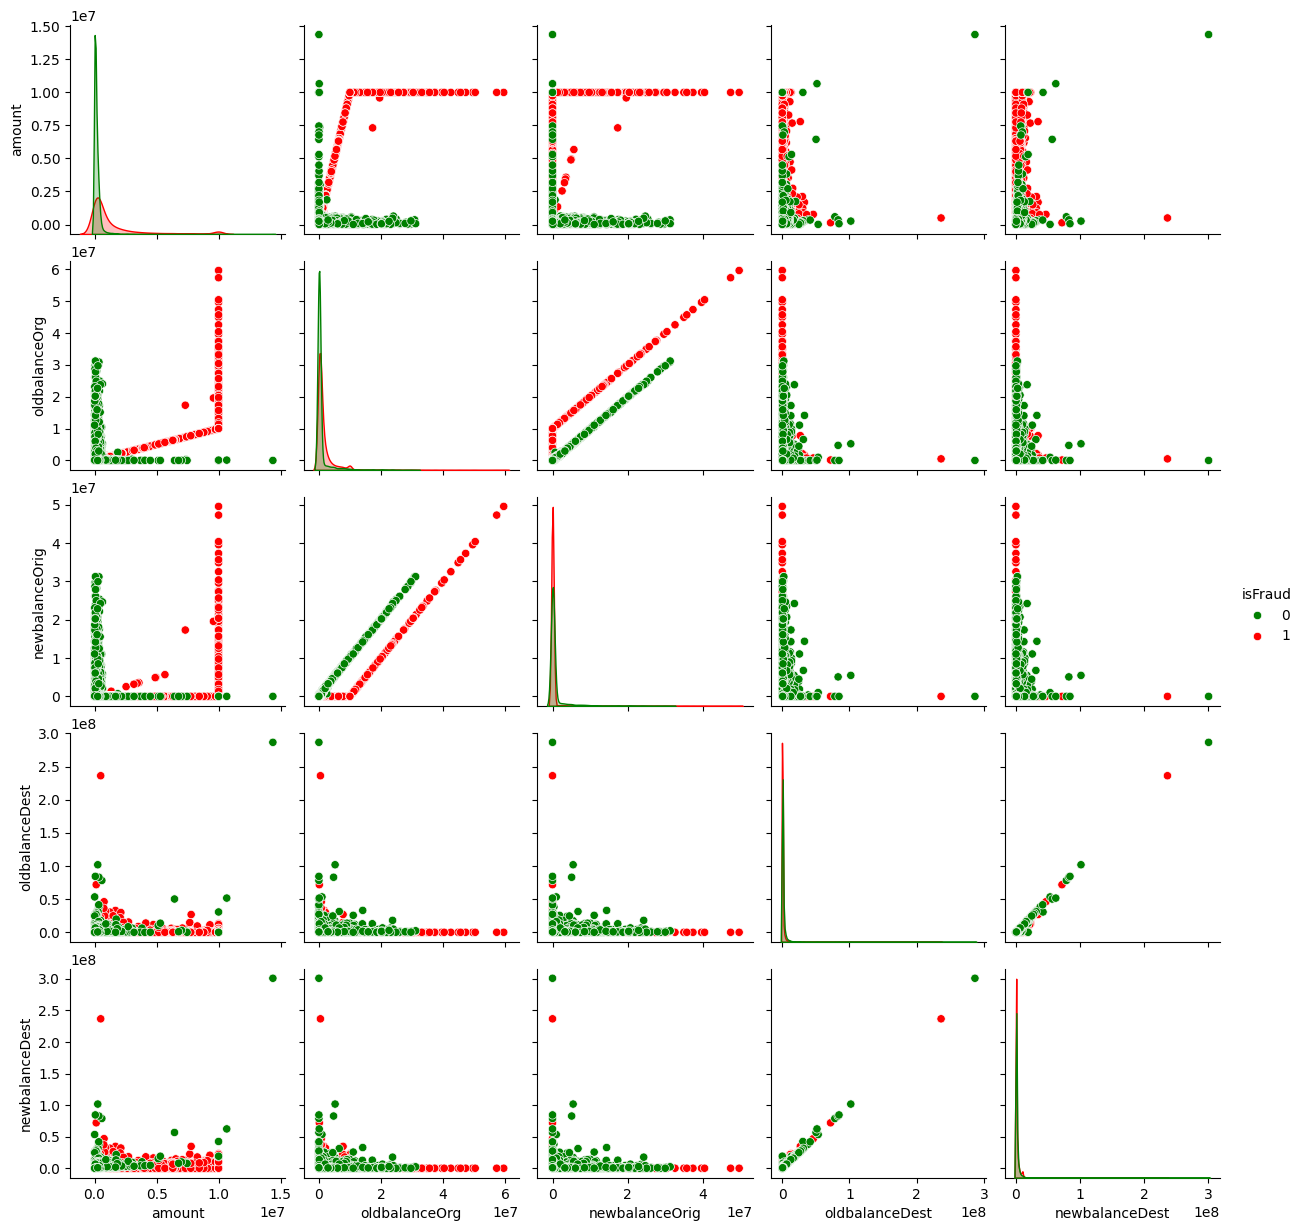

In [30]:
plt.figure(figsize= (15, 10))
cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
fraud = dataset[dataset['isFraud'] == 1]
non_fraud = dataset[dataset['isFraud'] == 0].sample(8213)

dataset_sample = pd.concat([fraud, non_fraud])

sns.pairplot(
    dataset_sample[cols],
    diag_kind='kde',
    hue= 'isFraud',
    palette= {1: 'red', 0: 'green'}
)
plt.show()

The dataset was imbalanced with 8213 fraud rows, so equal non-fraud samples were selected to balance it. Fraud shows higher amount and irregular balances with scattered extremes, while non-fraud is more structured.

In [31]:
dataset['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [32]:
type_mapping = {
    'PAYMENT': 1,
    'TRANSFER': 2,
    'CASH_OUT': 3,
    'DEBIT': 4,
    'CASH_IN': 5
}

dataset['type'] = dataset['type'].map(type_mapping)

In [33]:
corr = dataset.corr()
corr

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,OrgbalanceDiff,DestbalanceDiff
step,1.000000,-0.001992,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.007255,0.001325
type,-0.001992,1.000000,0.050693,0.415700,0.431006,0.165383,0.135362,-0.004463,-0.406708,-0.079747
amount,0.022373,0.050693,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.102337,0.845964
oldbalanceOrg,-0.010058,0.415700,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,-0.220297,-0.087032
newbalanceOrig,-0.010299,0.431006,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,-0.267750,-0.094456
oldbalanceDest,0.027665,0.165383,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.047460,0.232316
newbalanceDest,0.025888,0.135362,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.006451,0.436191
isFraud,0.031578,-0.004463,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.362472,0.027028
OrgbalanceDiff,0.007255,-0.406708,0.102337,-0.220297,-0.267750,-0.047460,-0.006451,0.362472,1.000000,0.169292
DestbalanceDiff,0.001325,-0.079747,0.845964,-0.087032,-0.094456,0.232316,0.436191,0.027028,0.169292,1.000000


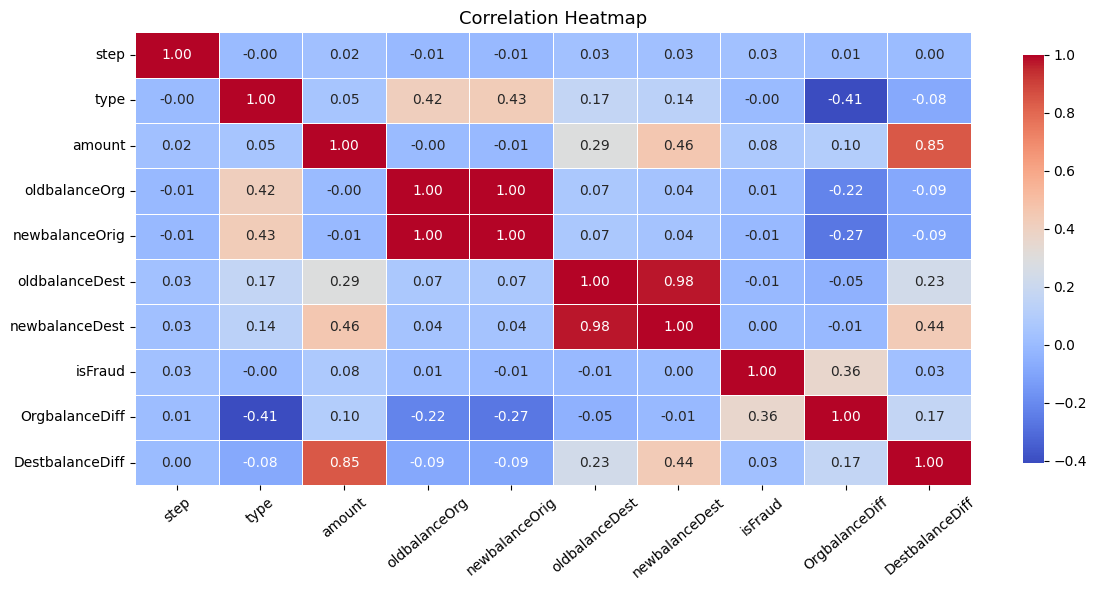

In [34]:
# Correlation heatmap
plt.figure(figsize=(12,6)) # Create a figure with width=12 and height=8

sns.heatmap(corr, # Data: correlation matrix
            annot=True, # Show correlation values inside cells
            fmt=".2f", # Format values to 2 decimal places
            cmap='coolwarm', # Color map (blue = negative, red = positive)
            linewidths=0.5, # Add lines between cells for better visibility
            cbar_kws={"shrink": 0.9} # Shrink the color bar size slightly
)

plt.title("Correlation Heatmap", fontsize=13) # Add title with font size
plt.xticks(rotation=40) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

Strong relationships exist among balance features, but correlation with fraud is weak, indicating fraud depends on combined feature interactions rather than individual variables.

In [35]:
dataset = dataset.drop(['step'], axis=1)

Train Test Split and Model Training

In [36]:
X = dataset.drop('isFraud', axis= 1)
y = dataset['isFraud']

In [37]:
X.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,OrgbalanceDiff,DestbalanceDiff
0,1,9839.64,170136.0,160296.36,0.0,0.0,9839.64,0.0
1,1,1864.28,21249.0,19384.72,0.0,0.0,1864.28,0.0
2,2,181.00,181.0,0.00,0.0,0.0,181.00,0.0
3,3,181.00,181.0,0.00,21182.0,0.0,181.00,-21182.0
4,1,11668.14,41554.0,29885.86,0.0,0.0,11668.14,0.0


In [38]:
y.value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [39]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
X_train.shape, X_test.shape

((5090096, 8), (1272524, 8))

In [41]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column           Dtype  
---  ------           -----  
 0   type             int64  
 1   amount           float64
 2   oldbalanceOrg    float64
 3   newbalanceOrig   float64
 4   oldbalanceDest   float64
 5   newbalanceDest   float64
 6   OrgbalanceDiff   float64
 7   DestbalanceDiff  float64
dtypes: float64(7), int64(1)
memory usage: 388.3 MB


Random Froest Classifier

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,
                               random_state=42,
                               n_jobs= -1,
                               class_weight= 'balanced') # for handling imbalance 
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
# Cross-Validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Stratified K-Fold (important for imbalance data)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Multiple scoring metrics (important for fraud detection)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='recall')

print('CV Recall Scores:', cv_scores)
print('Average CV Recall:', cv_scores.mean())

CV Recall Scores: [0.79984779 0.79299848 0.79984779 0.82343988 0.79452055]
Average CV Recall: 0.8021308980213089


In [44]:
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [50],
    'max_depth': [None],
    'min_samples_split': [5],
    'min_samples_leaf': [2]
}

X_sample = X_train.sample(400000, random_state=42)
y_sample = y_train.loc[X_sample.index]

# Random Search
random_search = RandomizedSearchCV(rf,
                                   param_distributions=param_dist,
                                   n_iter=5,
                                   scoring= 'recall',
                                   cv=2,
                                   verbose=1,
                                   random_state=42,
                                   n_jobs=-1
)

random_search.fit(X_sample, y_sample)
print('Best Parameters', random_search.best_params_)

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=5. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best Parameters {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}


In [45]:
# Training with best parameters
model = random_search.best_estimator_
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [46]:
# Prediction with Threshold Tuning
# y_pred = model.predict(X_test)

# Get predicted probabilities for class 1 (fraud)
y_prob = model.predict_proba(X_test)[:,1] # [:, 1] selects the probability of the positive class (fraud)

# Applied custom threshold (0.3 instead of default 0.5)
y_pred = (y_prob > 0.3).astype(int) # If probability > 0.3 --> predict fraud (1), else non-fraud (0)

In [47]:
# Final Evalution
from sklearn.metrics import classification_report, confusion_matrix
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[1270553     328]
 [    109    1534]]


In [48]:
print('Classification Report:\n',classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.82      0.93      0.88      1643

    accuracy                           1.00   1272524
   macro avg       0.91      0.97      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524



XGBClassifier

In [49]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1]),  # imbalance handling
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [50]:
# Cross-Validation
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results = cross_validate(xgb,
                            X_train, y_train,
                            cv=cv,
                            scoring=scoring,
                            n_jobs=-1
                            )

print('Precision:', cv_results['test_precision'].mean())
print('Recall:', cv_results['test_recall'].mean())
print('F1 Score:', cv_results['test_f1'].mean())

Precision: 0.1864955116510573
Recall: 0.9951293759512938
F1 Score: 0.31408327656620144


In [51]:
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100],
    'max_depth': [4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'gamma': [0, 1]
}

# Sample data (for speed)
X_sample = X_train.sample(400000, random_state=42)
y_sample = y_train.loc[X_sample.index]

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=5,
    scoring='f1',
    cv=2,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_sample, y_sample)

print("Best Parameters:", random_search.best_params_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 0.8}


In [52]:
# Training with best parameters
xgb_model = random_search.best_estimator_
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [53]:
# Prediction with Threshold Tuning
y_prob = model.predict_proba(X_test)[:, 1]

# Adjust threshold
y_pred = (y_prob > 0.4).astype(int)

In [54]:
# Final Evalution
from sklearn.metrics import classification_report, confusion_matrix

print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[1270680     201]
 [    168    1475]]


In [55]:
print('Classification Report:\n', classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.88      0.90      0.89      1643

    accuracy                           1.00   1272524
   macro avg       0.94      0.95      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524



After hyperparameter tuning, Random Forest further improved recall while maintaining strong precision and F1-score. In contrast, XGBoost showed a decrease in recall after tuning. Since high recall is crucial for fraud detection, Random Forest was ultimately chosen as the final model.

In [ ]:
import joblib

joblib.dump(model, 'online_fraud_model.pkl')

['online_fraud_model.pkl']